#VISUALISASI DATA STATIS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

# Style visualisasi
sns.set_style("whitegrid")

In [2]:
df = sns.load_dataset('tips')

print("Ukuran dataset:", df.shape)
print("\nTipe data:")
print(df.dtypes)

print("\n5 data pertama:")
print(df.head())

print("\nStatistik deskriptif:")
print(df.describe().round(2))

Ukuran dataset: (244, 7)

Tipe data:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

5 data pertama:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Statistik deskriptif:
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


/tmp/ipykernel_1062/1784347813.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_day = df.groupby('day')['total_bill'].mean()


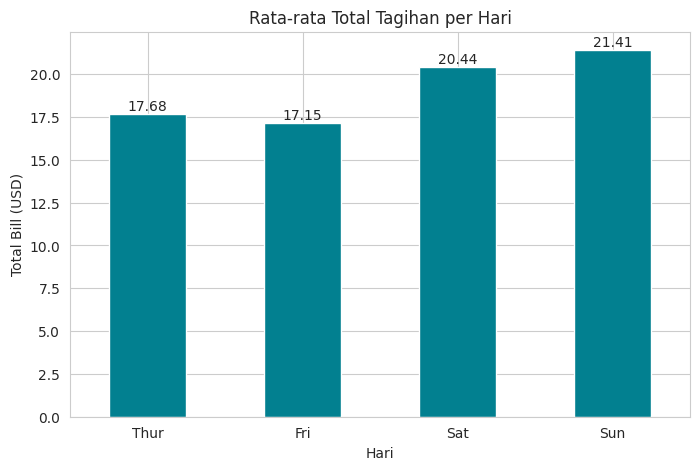

In [3]:
avg_by_day = df.groupby('day')['total_bill'].mean()

plt.figure(figsize=(8, 5))
avg_by_day.plot(
    kind='bar',
    color='#028090',
    edgecolor='white'
)

plt.title('Rata-rata Total Tagihan per Hari')
plt.xlabel('Hari')
plt.ylabel('Total Bill (USD)')
plt.xticks(rotation=0)

# Label nilai
for i, v in enumerate(avg_by_day):
    plt.text(i, v + 0.2, f'{v:.2f}', ha='center')

plt.show()

## Analisis Grafik 1 — Bar Chart

**What?**  
Grafik menunjukkan bahwa hari Minggu (Sun) memiliki rata-rata total tagihan tertinggi, yaitu sekitar 21,41 USD. Hari Jumat (Fri) memiliki rata-rata terendah, yaitu sekitar 17,15 USD.

**So What?**  
Hal ini menunjukkan bahwa pelanggan cenderung mengeluarkan uang lebih besar pada akhir pekan, terutama hari Minggu.

**Now What?**  
Restoran dapat menambah promosi atau kapasitas layanan pada akhir pekan untuk memaksimalkan pendapatan.

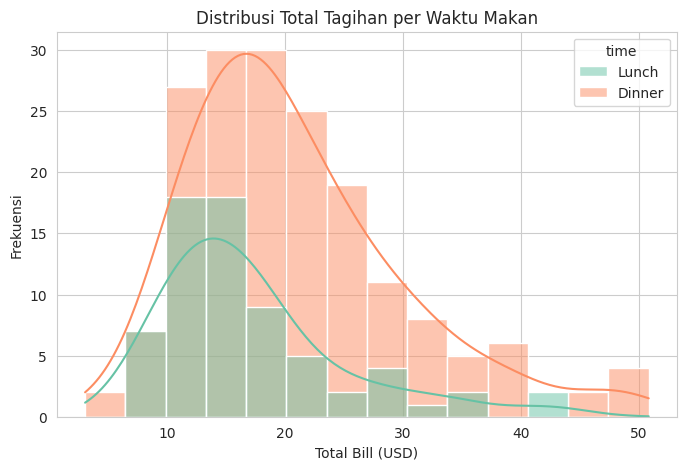

In [4]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='total_bill',
    hue='time',
    kde=True,
    palette='Set2'
)

plt.title('Distribusi Total Tagihan per Waktu Makan')
plt.xlabel('Total Bill (USD)')
plt.ylabel('Frekuensi')
plt.show()

## Analisis Grafik 2 — Histogram

**What?**  
Sebagian besar total tagihan berada pada rentang 10–25 USD. Distribusi cenderung miring ke kanan dengan beberapa transaksi di atas 50 USD.

**So What?**  
Mayoritas transaksi bernilai sedang, namun terdapat sejumlah kecil transaksi besar yang berkontribusi signifikan terhadap pendapatan.

**Now What?**  
Perlu dianalisis apakah transaksi besar lebih sering terjadi saat Dinner atau ketika jumlah tamu lebih banyak.

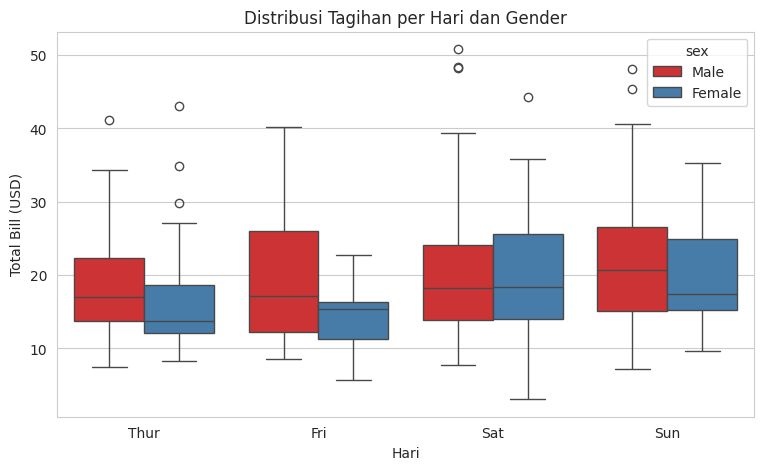

In [5]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='day',
    y='total_bill',
    hue='sex',
    palette='Set1'
)

plt.title('Distribusi Tagihan per Hari dan Gender')
plt.xlabel('Hari')
plt.ylabel('Total Bill (USD)')
plt.show()

## Analisis Grafik 3 — Boxplot

**What?**  
Median total tagihan pada hari Sabtu dan Minggu lebih tinggi dibanding hari lainnya. Terdapat beberapa outlier dengan nilai tagihan yang sangat tinggi.

**So What?**  
Hal ini menunjukkan adanya pelanggan dengan pengeluaran besar yang dapat menjadi segmen potensial bagi restoran.

**Now What?**  
Restoran dapat mempelajari karakteristik pelanggan dengan tagihan tinggi untuk menyusun strategi pemasaran yang lebih tepat.

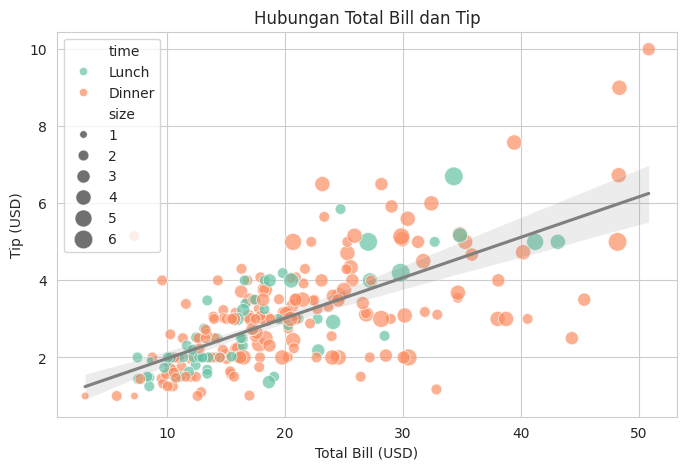

In [6]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='total_bill',
    y='tip',
    hue='time',
    size='size',
    sizes=(30, 180),
    palette='Set2',
    alpha=0.7
)

sns.regplot(
    data=df,
    x='total_bill',
    y='tip',
    scatter=False,
    color='gray'
)

plt.title('Hubungan Total Bill dan Tip')
plt.xlabel('Total Bill (USD)')
plt.ylabel('Tip (USD)')
plt.show()

## Analisis Grafik 4 — Scatter Plot

**What?**  
Terdapat hubungan positif antara total tagihan dan tip. Semakin besar total tagihan, semakin besar tip yang diberikan.

**So What?**  
Peningkatan nilai transaksi berpotensi meningkatkan pendapatan pelayan melalui tip yang lebih besar.

**Now What?**  
Analisis lanjutan dapat menghitung persentase tip untuk mengetahui konsistensi pelanggan dalam memberi tip.

Dashboard 2x2

/tmp/ipykernel_1062/244742828.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_day = df.groupby('day')['total_bill'].mean()


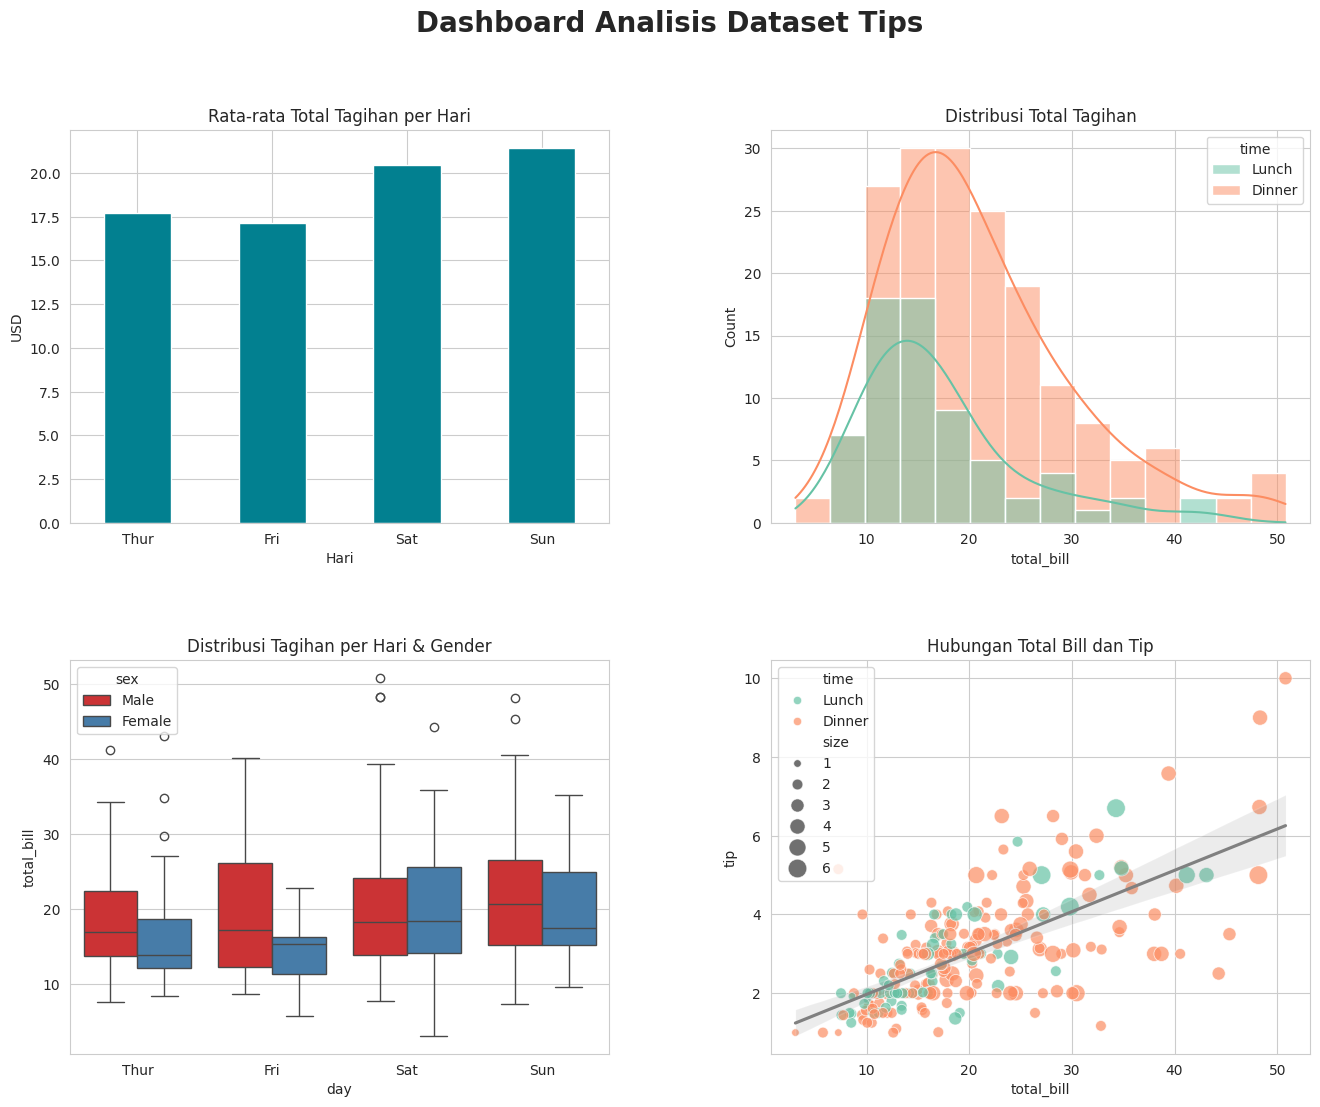

Dashboard tersimpan sebagai dashboard_tips.png


In [7]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Dataset Tips', fontsize=20, fontweight='bold')

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.30)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# 1. Bar Chart
avg_by_day = df.groupby('day')['total_bill'].mean()
avg_by_day.plot(kind='bar', ax=ax1, color='#028090', edgecolor='white')
ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari')
ax1.set_ylabel('USD')
ax1.tick_params(axis='x', rotation=0)

# 2. Histogram
sns.histplot(data=df, x='total_bill', hue='time', kde=True, palette='Set2', ax=ax2)
ax2.set_title('Distribusi Total Tagihan')

# 3. Boxplot
sns.boxplot(data=df, x='day', y='total_bill', hue='sex', palette='Set1', ax=ax3)
ax3.set_title('Distribusi Tagihan per Hari & Gender')

# 4. Scatter Plot
sns.scatterplot(
    data=df,
    x='total_bill',
    y='tip',
    hue='time',
    size='size',
    sizes=(30, 180),
    palette='Set2',
    alpha=0.7,
    ax=ax4
)
sns.regplot(data=df, x='total_bill', y='tip', scatter=False, color='gray', ax=ax4)
ax4.set_title('Hubungan Total Bill dan Tip')

plt.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show()

print("Dashboard tersimpan sebagai dashboard_tips.png")